# Tema di esame 4: classificazione di tumori benigni e maligni
## Autori: *Barbieri Mosè* - *Foschi Jacopo*

# 1. Introduzione del problema

In campo medico il machine learning viene sempre più utilizzato per riuscire a identificare e classificare tumori di vario genere. Una sempre maggior automazione di questi processi, che prima venivano fatti solamente a mano, permette non solo di risparmiare tempo ai medici, che possono quindi fare più sessioni di screening e in ultimo salvare potenzialmente più persone; ma permette anche di riconoscere e classificare correttamente tumori in uno stato dove all'occhio umano non risulterebbe ancora riconoscibile.

Nel caso specifico preso in esame, partendo da tumori già identificati, misurati e correttamente diagnosticati come benigni e maligni, si vuole riproporre questo processo di ML per rendere automatica, rapida e soprattutto corretta questa classificazione.

- Problema: una volta identificata la presenza di una massa, differenziare e classificare correttamente i tumori benigni da quelli maligni
- Tipo di task: classificazione binaria supervisionata
- Obiettivo del progetto: sviluppare un modello di classificazione che massimizzi la Recall (quanti positivi siano stati correttamente identificati), per evitare che tumori maligni passino inosservati
- Interesse pratico: un tumore maligno non controllato ha un grande rischio di degenerare in metastasi portando al decesso della persona, lo scopo è perciò di salvare la vita alle persone.

# 2. Descrizione del dataset

- Origine del dataset: dataset già precaricato in scikit learn
- descrizione delle variabili:

| Categoria | Variabili ( `mean *`, `* error`, `worst *`) |
|---|---|
| Radius | `mean radius`, `radius error`, `worst radius` |
| Texture | `mean texture`, `texture error`, `worst texture` |
| Perimeter | `mean perimeter`, `perimeter error`, `worst perimeter` |
| Area | `mean area`, `area error`, `worst area` |
| Smoothness | `mean smoothness`, `smoothness error`, `worst smoothness` |
| Compactness | `mean compactness`, `compactness error`, `worst compactness` |
| Concavity | `mean concavity`, `concavity error`, `worst concavity` |
| Concave points | `mean concave points`, `concave points error`, `worst concave points` |
| Symmetry | `mean symmetry`, `symmetry error`, `worst symmetry` |
| Fractal dimension | `mean fractal dimension`, `fractal dimension error`, `worst fractal dimension` |
| **Target** | **`target`** (0 = maligno, 1 = benigno) |

- Variabile target: target - variabile binaria che esprime se il tumore è benigno (1) o maligno(0).
- Dimensione del dataset: 569 record su 31 colonne (10 feature * 3 caratteristiche ciascuno e 1 target)
- Note: in quanto questi dati originano da misurazioni reali fatte in campo medico, eventuali outlier saranno da considerarsi fondamentali, poiché oltre a essere probabilmente la chiave di riconoscimento dei tumori maligni, non si può assolutamente escludere anche un solo dato reale mettendo a rischio la vita delle persone


# 3. Lettura e preparazione dei dati

Procediamo caricando il dataset da scikit learn e importando le varie librerie canoniche che potranno tornarci utili

In [16]:
import sklearn as sk
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

Procediamo con l'espolorazione del dataset

In [17]:
df = load_breast_cancer(as_frame=True).frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Per confermare immidiatamente a cosa si riferisce la variabile target, chiediamo direttamente al dataset

In [18]:
complete_df = load_breast_cancer()
print(complete_df.target_names)

['malignant' 'benign']


L'indice ci conferma che:
- **Maligno** = 0
- **Benigno** = 1

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

Essendo questo un dataset medico già pre-elaborato, non risultano esserci valori nulli. Inoltre il tipo delle variabili è già consistente e corretto, di conseguenza non saranno necessarie trasformazioni al di fuori del normale scaling.


# 4. Visualizzazione ed EDA


Procediamo analizzando i percentili, il massimo, la deviazione standardad e la media

In [20]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Confrontando i percentili con la media e il massimo, diventa evidente come ci siano dei forti outlier, cosa che andremo a confermare in seguito

È tempo di analizzare se è presente squilibrio tra le due classi: Benigno e Maligno

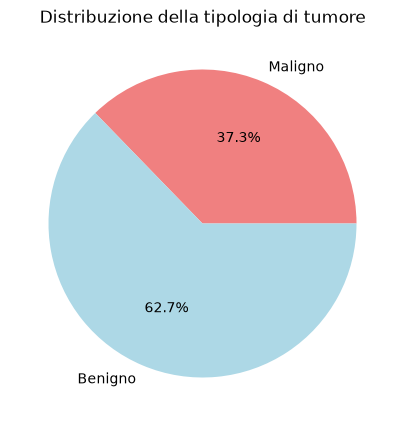

In [21]:
# Mostriamo la distribuzione delle classi tramite un grafico a torta 
df['target'].value_counts().sort_index().plot.pie( labels=['Maligno', 'Benigno'], colors=['lightcoral', 'lightblue'], autopct='%1.1f%%', figsize=(5, 5), title='Distribuzione della tipologia di tumore', ylabel='');

Il dataset è moderatamente sbilanciato, cosa che dovrà essere tenuta in conto successivamente

Passiamo adesso ad analizzare tutte le correlazioni tra le varie feture e le loro "varianze".

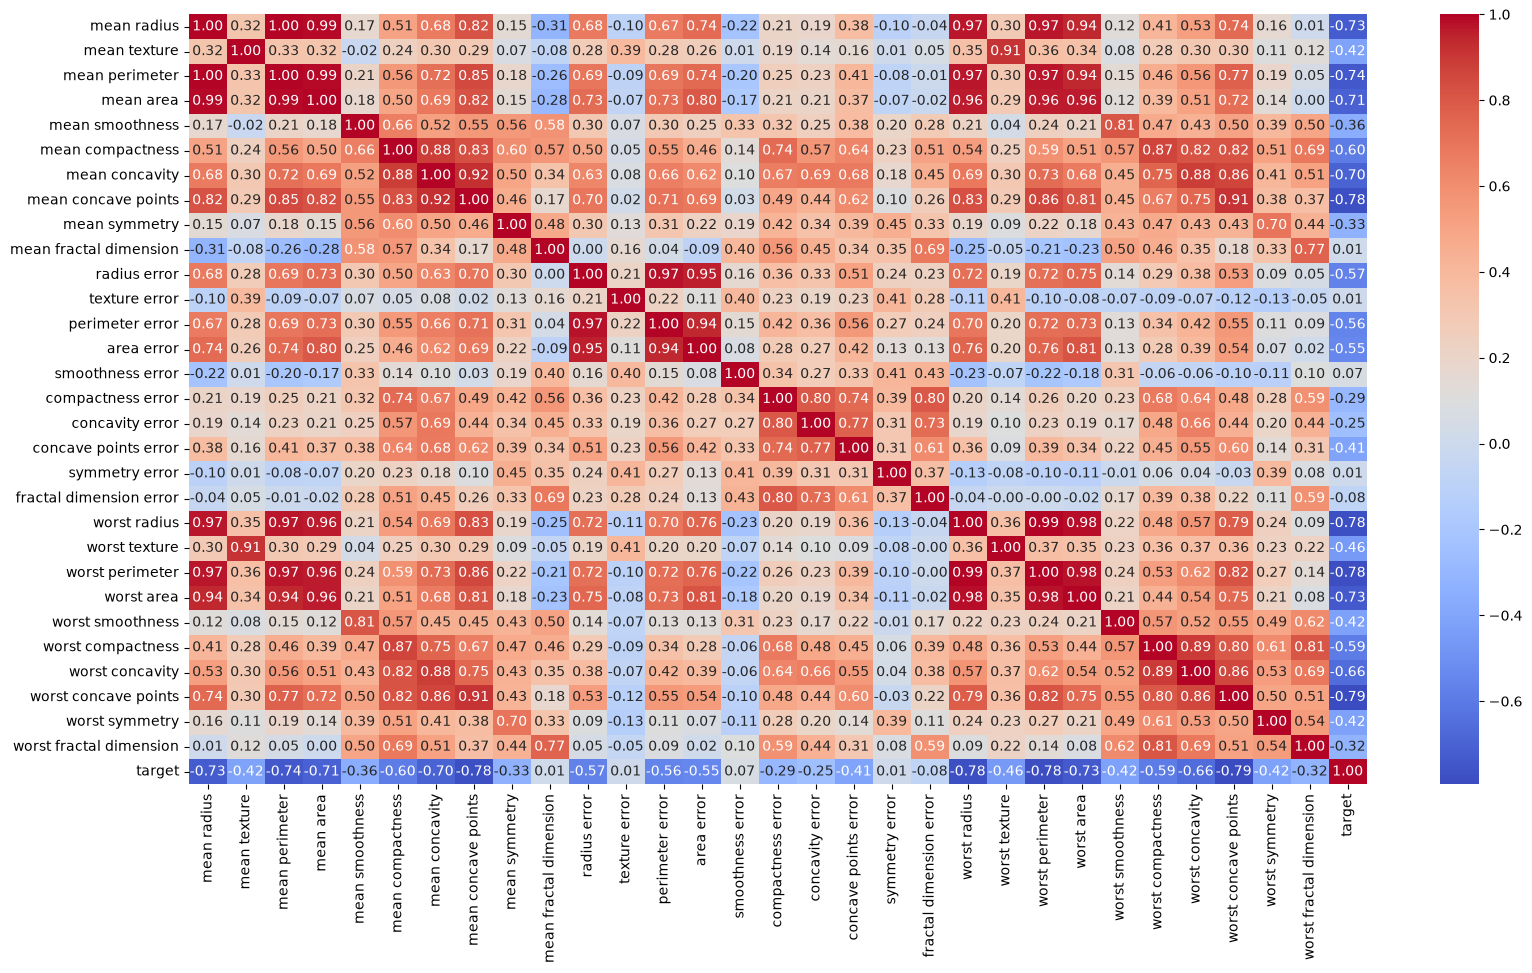

In [22]:
# Analizziamo la correlazione tra le variabili tramite una heatmap
plt.figure(figsize=(19, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f');

Analizzando tra le variabili, si può notare che, come ci si poteva aspettare: area, perimeter e radius sono strettamente correlati. Inoltre questa heat-map mostra anche le varie "varianze" delle feature e come si legano tra di loro.

Le altre coppie che assumono molta rilevanza sono: 

- Worst Compactness e Worst Concave Points : 0.80
- Worst Concavity e Worst Concave Points : 0.86
- Mean Compactness e Worst Compactness : 0.87
- Mean Concavity e Worst Concavity : 0.88
- Worst Compactness e Worst Concavity : 0.89
- Mean Concave Points e Worst Concave Points : 0.91
- Mean Concavity e Mean Concave Points : 0.92


Adesso attraverso un pairPlot cerchiamo di analizzare tutte le varie coppie tenendo conto deii valori delle "worst", che molto probabilmente, data la loro forte correlazione riescono a determinare facilmente la malignità o benignità del tumore.

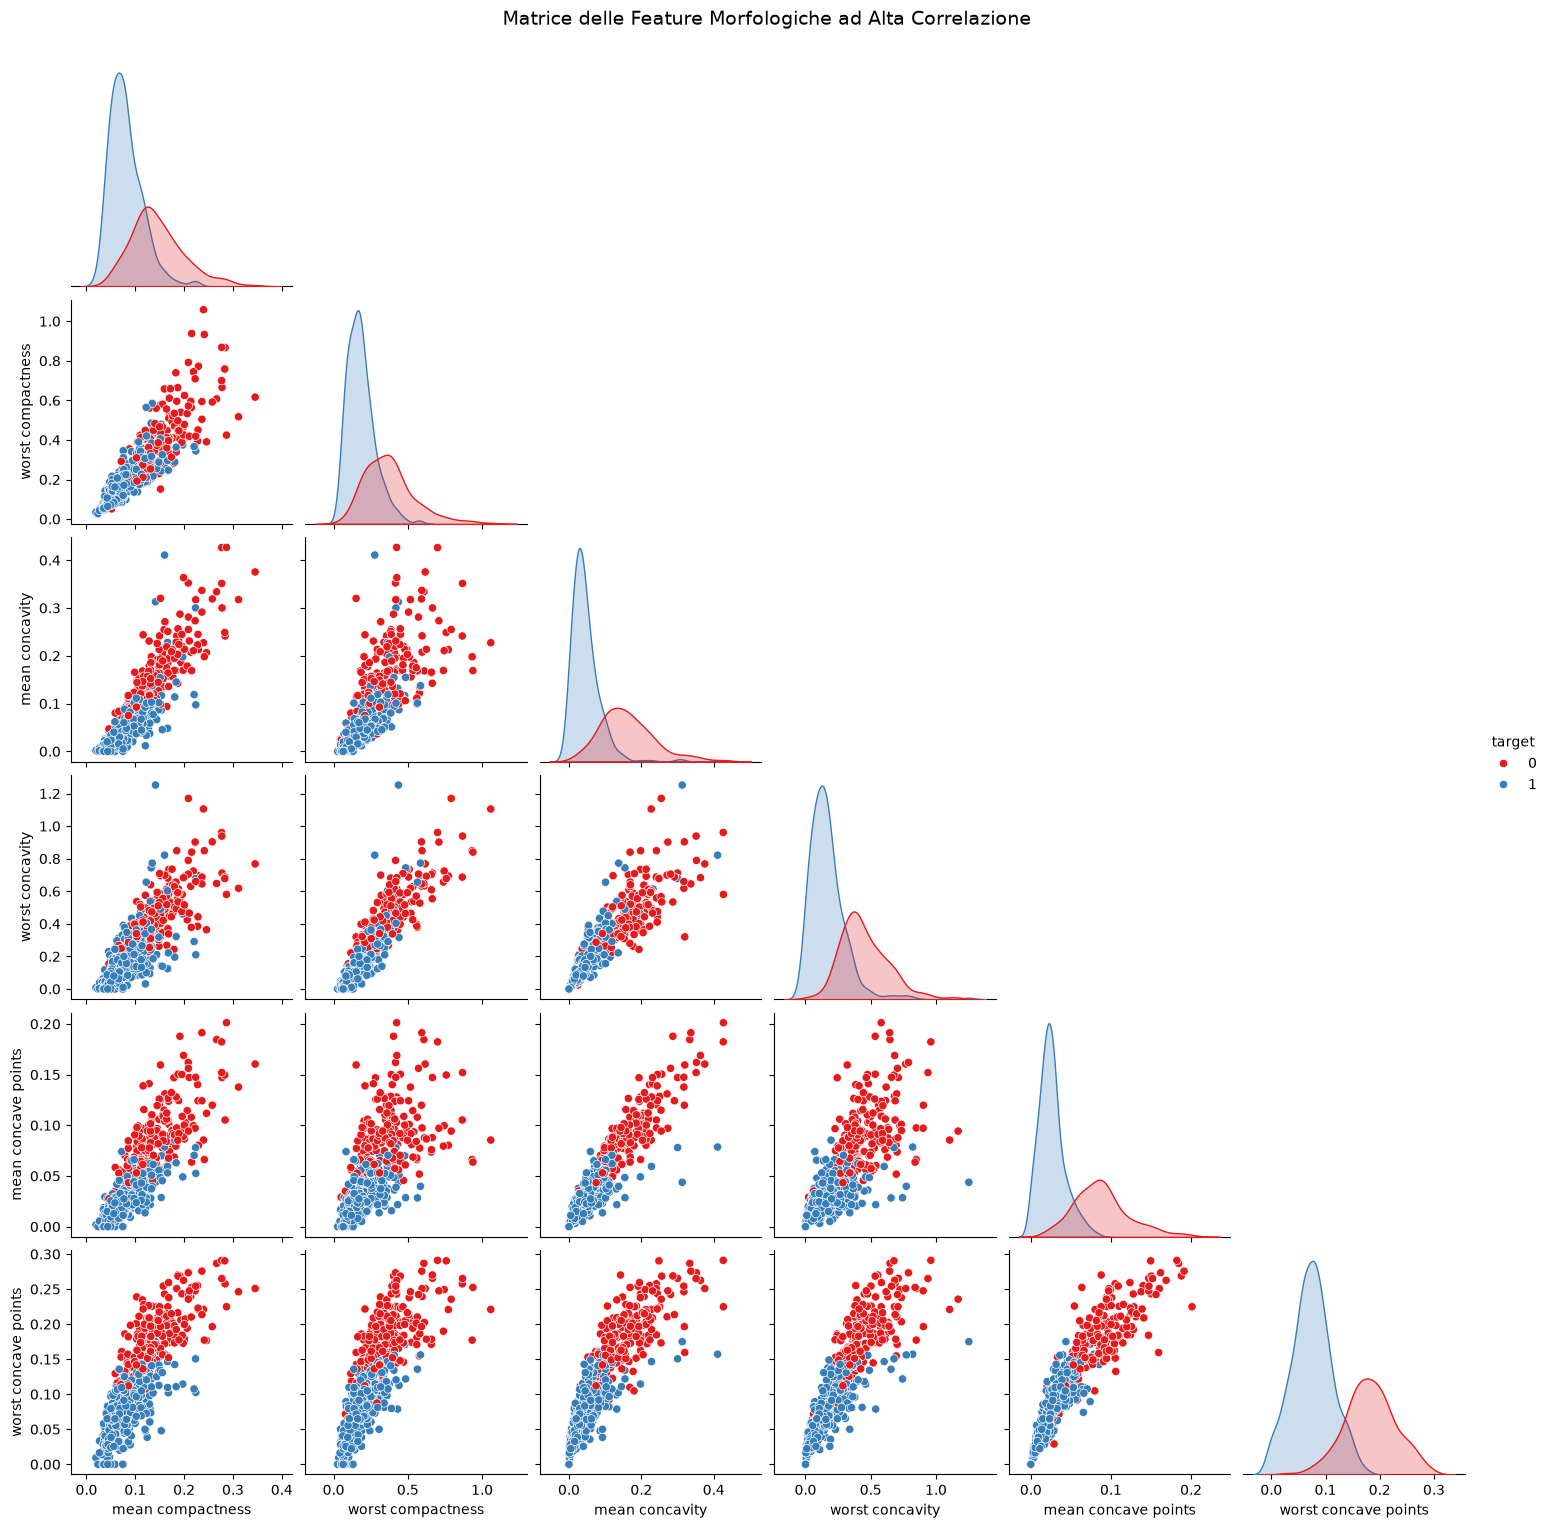

In [23]:
# Lista ottimizzata: ogni feature è stata selezionata in base alla sua correlazione con le altre e con il target.
features_ottimizzate = [
    'mean compactness', 'worst compactness',
    'mean concavity', 'worst concavity',
    'mean concave points', 'worst concave points',
    'target'
]

# Creazione della pairplot per visualizzare le relazioni tra le feature selezionate
# lo hue è impostato sul target per distinguere tra tumori benigni e maligni.
sns.pairplot(df[features_ottimizzate], hue='target', palette='Set1', corner=True, diag_kind='kde')

plt.suptitle("Matrice delle Feature Morfologiche ad Alta Correlazione", y=1.02, fontsize=14)
plt.show()

Come volevasi dimostrare le "worst" feture riescono a dividere al meglio la variabile target rendendole così papabili da utilizzare all'interno dei vari modelli. In questo modo pensiamo di riuscire a predire l'esito di analisi sulla malignità o benignità del tumore in maniera ottimale. 

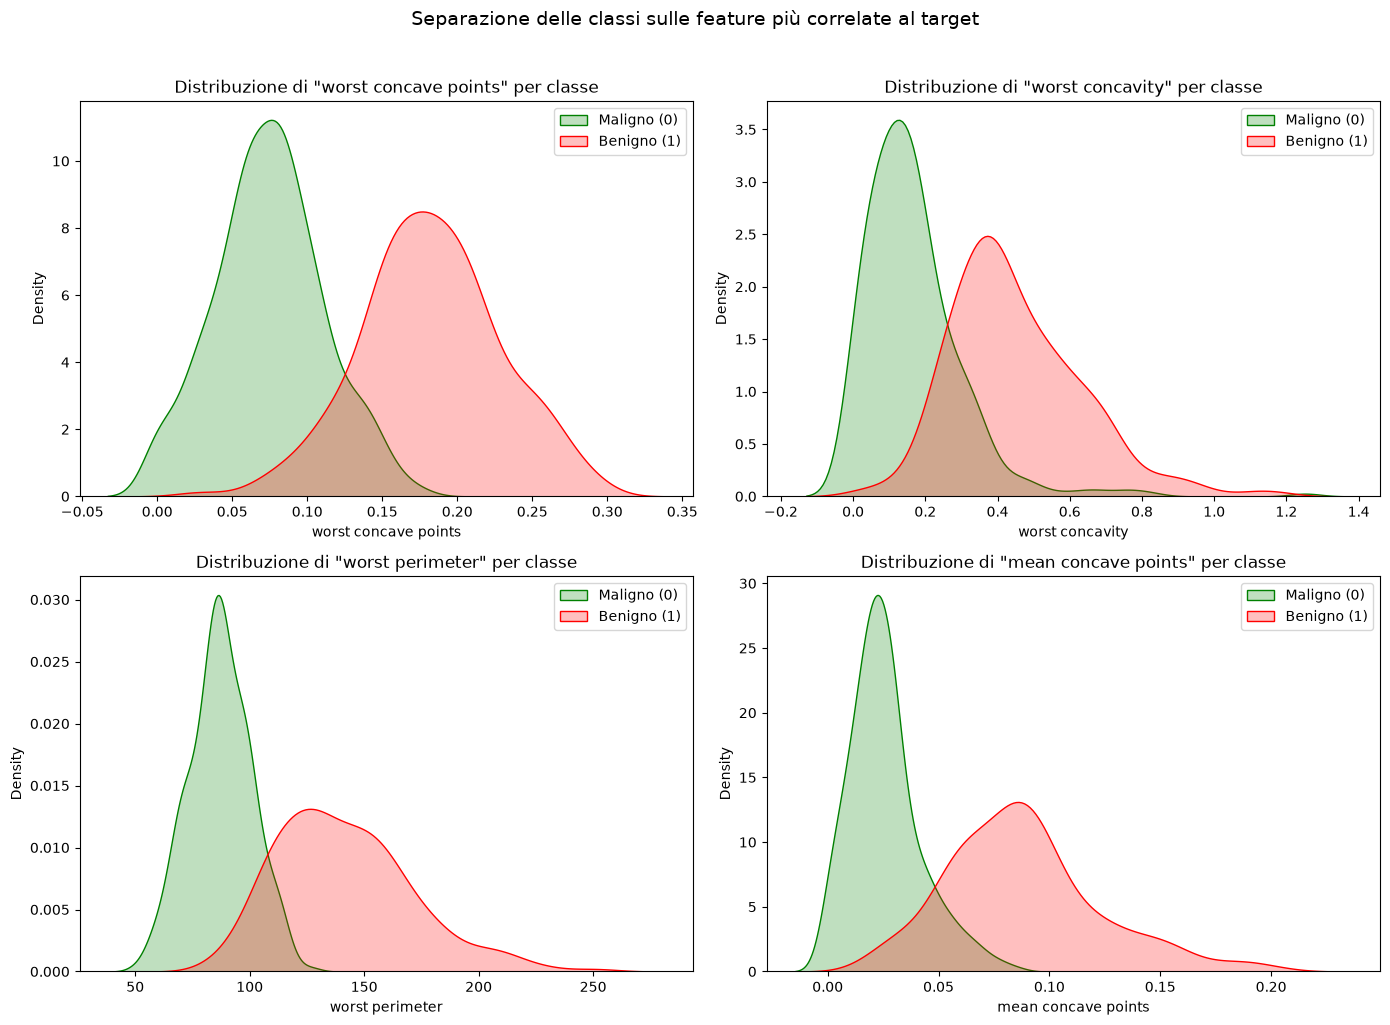

In [24]:
# Distribuzione delle feature più discriminanti, suddivise per classe
features_kde = ['worst concave points', 'worst concavity', 'worst perimeter', 'mean concave points']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(features_kde):
    sns.kdeplot(data=df, x=feature, hue='target', fill=True,
                palette={0: 'red', 1: 'green'}, common_norm=False, ax=axes[i])
    axes[i].set_title(f'Distribuzione di "{feature}" per classe')
    axes[i].legend(labels=['Maligno (0)', 'Benigno (1)'])

plt.suptitle('Separazione delle classi sulle feature più correlate al target', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Osservazioni conclusive dell'EDA:**

- Il dataset presenta uno sbilanciamento moderato tra le classi (circa 63% benigni, 37% maligni), da tenere in considerazione nella fase di modellazione (es. stratificazione nello split).
- Le feature legate a forma e concavità della massa (in particolare le variabili "worst") mostrano la separazione più netta tra tumori benigni e maligni, e saranno probabilmente le più informative per i modelli di classificazione.
- Esiste forte correlazione tra gruppi di feature (es. area/perimeter/radius, e le coppie mean/worst della stessa misura), un aspetto da considerare in fase di preprocessing per evitare ridondanza eccessiva.

# 5. Outlier detection / preprocessing

Come premessa, già espressa in precedenza, che ci sentiamo di comunicare è che in ambito medico, come in questo caso, gli outlier non dovrebbero essere rimossi. Sia eticamente che anche ai fini della Recall: essenzialmente se venissero tolti si rischierebbe di togliere dei casi estremi già documentati e che quindi potrebbero essere la chiave per salvare più vite. Perciò il nostro obbiettivo è cercare di studiare i vari outlier senza eliminarli dal dataset. 


In questa sezione analizziamo la presenza di valori anomali nelle feature del dataset, utilizzando il metodo dell'IQR (Interquartile Range). Per questo motivo, oltre a contare gli outlier, verifichiamo se sono associati prevalentemente alla classe maligna prima di decidere come trattarli.

In [25]:
# Selezioniamo solo le feature numeriche (escludendo target)
feature_cols = df.columns.drop('target')

outlier_summary = []

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    n_outliers = mask.sum()
    pct_malignant = df.loc[mask, 'target'].eq(0).mean() * 100 if n_outliers > 0 else 0

    outlier_summary.append({
        'feature': col,
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(df) * 100, 2),
        'pct_maligni_tra_outlier': round(pct_malignant, 1)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
outlier_df.head(15)

,feature,n_outliers,pct_outliers,pct_maligni_tra_outlier
13,area error,65,11.42,100.0
10,radius error,38,6.68,97.4
12,perimeter error,38,6.68,100.0
23,worst area,35,6.15,100.0
14,smoothness error,30,5.27,13.3
19,fractal dimension error,28,4.92,35.7
15,compactness error,28,4.92,50.0
18,symmetry error,27,4.75,59.3
3,mean area,25,4.39,100.0
29,worst fractal dimension,24,4.22,75.0


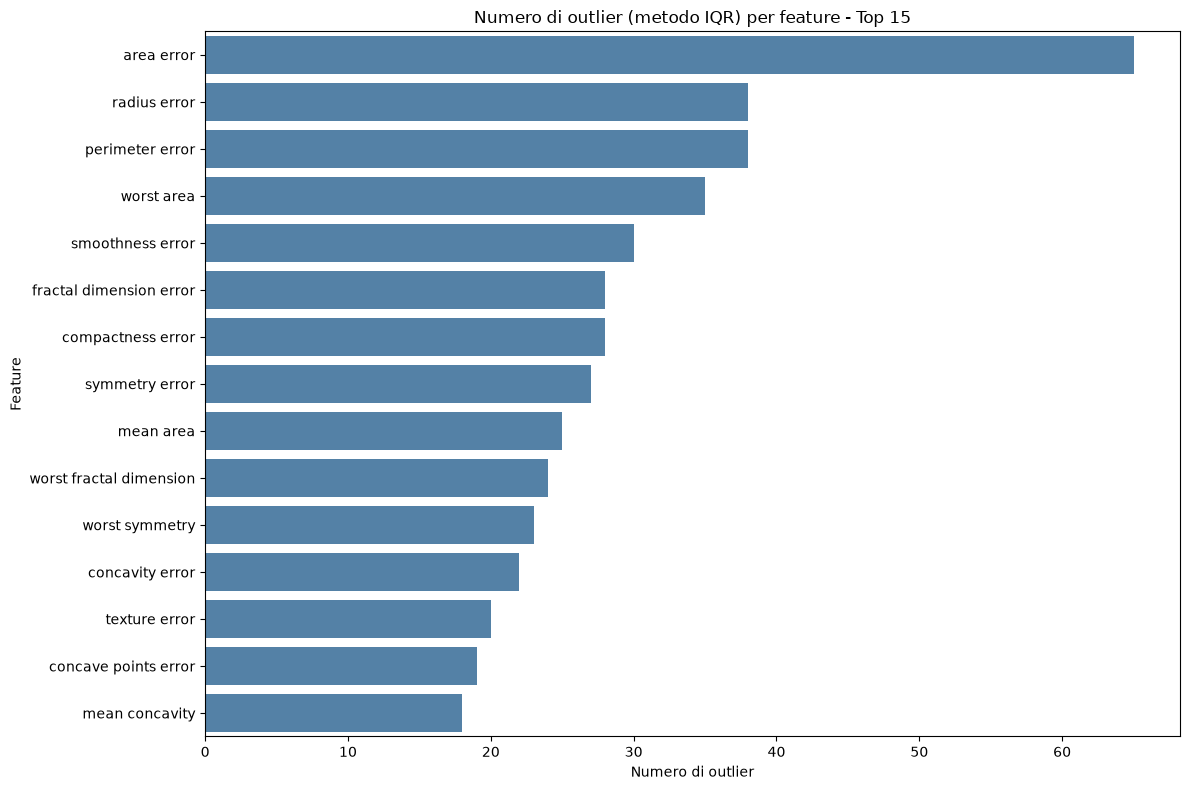

In [26]:
plt.figure(figsize=(12, 8))
sns.barplot(data=outlier_df.head(15), y='feature', x='n_outliers', color='steelblue')
plt.title('Numero di outlier (metodo IQR) per feature - Top 15')
plt.xlabel('Numero di outlier')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

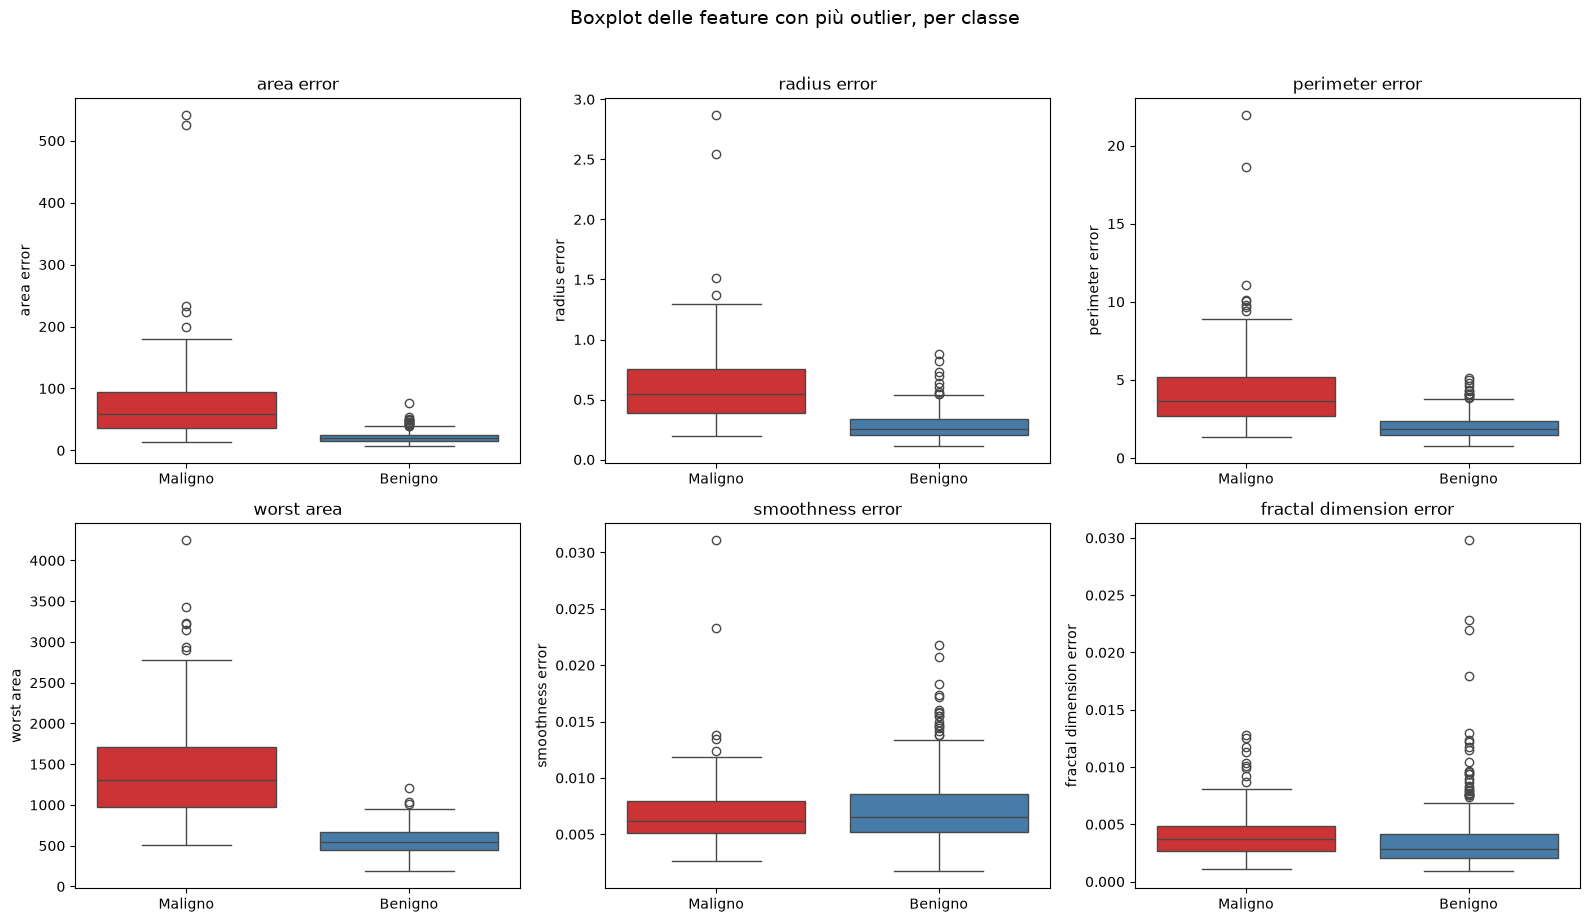

In [27]:
# Prendiamo le top 6 feature per numero di outlier (dalla tabella già calcolata)
top_features = outlier_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    sns.boxplot(data=df, x='target', y=feature, hue='target',
                palette="Set1", legend=False, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Maligno', 'Benigno'])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.suptitle('Boxplot delle feature con più outlier, per classe', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

I boxplot confermano quanto emerso dall'analisi numerica: per le feature con più outlier (es. worst concavity, worst concave points), i valori estremi si concentrano soprattutto nella classe maligna, che mostra sistematicamente code più lunghe e valori mediani più alti rispetto alla classe benigna. Questo pattern è coerente con l'interpretazione clinica: le forme più irregolari e "aggressive" appartengono tipicamente a masse maligne. Confermiamo quindi la decisione di non rimuovere questi outlier, in quanto rappresentano informazione utile per la classificazione piuttosto che rumore.

**Osservazioni:**

- Le feature con più outlier sono in gran parte quelle già identificate come più discriminanti nella sezione EDA (concavity, concave points, area), e in molti casi la percentuale di casi maligni tra gli outlier è nettamente superiore al 37% presente nel dataset complessivo, segno che queste feature sono fondamentali e fanno da carta tornasole per una corretta classificazione
- **Decisione**: non rimuoviamo questi valori dal dataset. Eliminarli rischierebbe di togliere proprio i casi più informativi per riconoscere un tumore maligno, andando contro l'obiettivo del progetto (massimizzare la recall sulla classe maligna). 
- Si procede quindi senza rimozione di outlier, ma con uno scaling delle feature (necessario per modelli come Logistic Regression, SVM e MLP) nella fase di preprocessing pre-modello.

Nota: l'analisi qui condotta è di tipo univariato (una feature alla volta). Un'analisi multivariata potrebbe individuare combinazioni di valori anomale anche quando le singole feature rientrano nei range normali; questo aspetto viene lasciato come possibile estensione futura.

# 6. Implementazione di uno o più modelli

Per il task di classificazione binaria (tumore maligno vs benigno) abbiamo scelto di confrontare più modelli con caratteristiche diverse, per capire quale si adatta meglio al problema e all'obiettivo specifico di massimizzare la Recall sulla classe maligna.

**Modelli scelti:**

- **Logistic Regression**: modello lineare, semplice e interpretabile. Utile come baseline: i coefficienti indicano direttamente quanto ogni feature contribuisce alla probabilità di malignità.
- **Support Vector Machine (SVM)**: efficace su dataset con molte feature come il nostro, e grazie a kernel non lineare può catturare relazioni più complesse tra le variabili morfologiche.
- **Random Forest**: modello ad albero, robusto agli outlier e alla multicollinearità, e fornisce anche una stima dell'importanza delle feature.
- **MLP**: rete neurale in grado di approssimare le relazioni complesse senza bisogno di specificare prima la forma delle relazioni tra le feature.

**Strategia di validazione:**

Per ogni modello utilizziamo:
- Uno split train/test (80/20) uguale per tutti i modelli per meglio compararli sulla base degli stessi input
- una cross-validation a 5 fold (StratifiedKFold) sul train set, per avere una stima più robusta delle performance e per il tuning degli iperparametri, prima della valutazione finale sul test set

Scaler e modello vengono incapsulati in una Pipeline, per evitare data leakage durante la cross-validation (lo scaling viene rifatto correttamente ad ogni fold, usando solo i dati di training di quel fold).

In [28]:
from sklearn.model_selection import train_test_split

# Separiamo feature e target
X = df.drop(columns='target')
y = df['target']

# Split stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 6.1 Regressione Logistica

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


Recall media in CV: 0.98
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



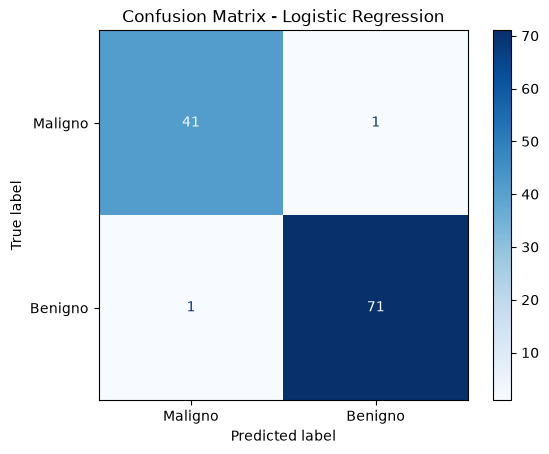

In [30]:
# Pipeline: scaler + modello in un unico oggetto
pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Cross-validation sul train set, con focus sulla recall della classe maligna (0), 
# con anche shuffling dei dati per garantire una distribuzione più equilibrata tra i fold.
# NB: verrà riutilizzato anche per gli altri modelli, quindi lo definiamo una volta sola.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_logreg = cross_val_score(pipe_logreg, X_train, y_train, cv=cv, scoring='recall_macro')

print(f"Recall media in CV: {scores_logreg.mean():.2f}")

# Addestramento finale sul train set completo
pipe_logreg.fit(X_train, y_train)

# Valutazione sul test set
y_pred_logreg = pipe_logreg.predict(X_test)

print(classification_report(y_test, y_pred_logreg, target_names=['Maligno', 'Benigno']))

# Confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=['Maligno', 'Benigno'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

I risultati promettono bene, la recall è alta ma comunque in campo medico sarebbe meglio averla al massimo, proprio per evitare i falsi negativi e mettere a repentaglio la vita delle persone. 

## 6.2 SVM

In [31]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

Per questo e i prossimi modelli, continueremo ad usare gli stessi dataset di train e test per meglio comparare le performance di ognuno. Inoltre per questi modelli più complessi, andremo a utilizzare varie configurazioni di parametri per eleggere il modello migliore con GridSearchCV

Recall media in CV: 0.97
Migliore configurazione: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__kernel': 'rbf'}
              precision    recall  f1-score   support

     Maligno       0.93      0.98      0.95        42
     Benigno       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



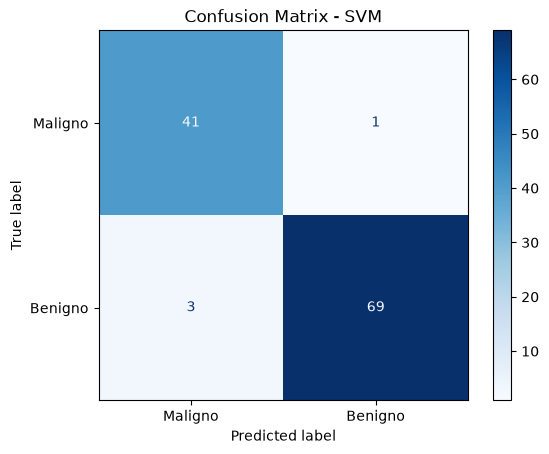

In [32]:
# Pipeline: scaler + modello in un unico oggetto
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=42))
])

param_grid_svm = {
    'clf__kernel': ['rbf', 'poly', 'linear'],
    'clf__class_weight': [None, 'balanced'],
    'clf__C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=cv, scoring='recall_macro', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print(f"Recall media in CV: {grid_svm.best_score_:.2f}")
print(f"Migliore configurazione: {grid_svm.best_params_}")

# Estraiamo il modello migliore trovato dalla grid search
best_svm = grid_svm.best_estimator_

# Valutazione sul test set
y_pred_svm = best_svm.predict(X_test)

print(classification_report(y_test, y_pred_svm, target_names=['Maligno', 'Benigno']))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Maligno', 'Benigno'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.show()

I risultati qui sono diversi. L'elezione del modello migliore ne ha preferito uno con una precisione più bassa ma con una recall per i tumori maligni invariata. Se venisse utilizzato nella realtà porterebbe a uno spreco maggiore di risorse sanitarie a causa di screening o cure non necessarie.

## 6.3 Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

Recall media in CV: 0.96
              precision    recall  f1-score   support

     Maligno       0.91      0.95      0.93        42
     Benigno       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



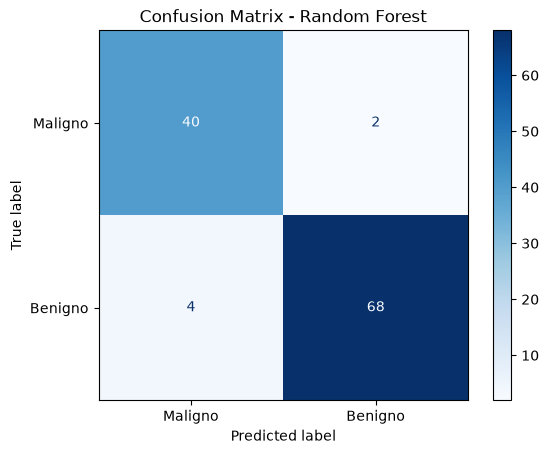

In [34]:
# Pipeline: scaler + modello in un unico oggetto
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [25, 50, 100, 200],
    'clf__max_depth': [None, 5, 10, 15, 20],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(pipe_rf, param_grid, cv=cv, scoring='recall_macro', n_jobs=-1)

grid_rf.fit(X_train, y_train)

print(f"Recall media in CV: {grid_rf.best_score_:.2f}")

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['Maligno', 'Benigno']))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Maligno', 'Benigno'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

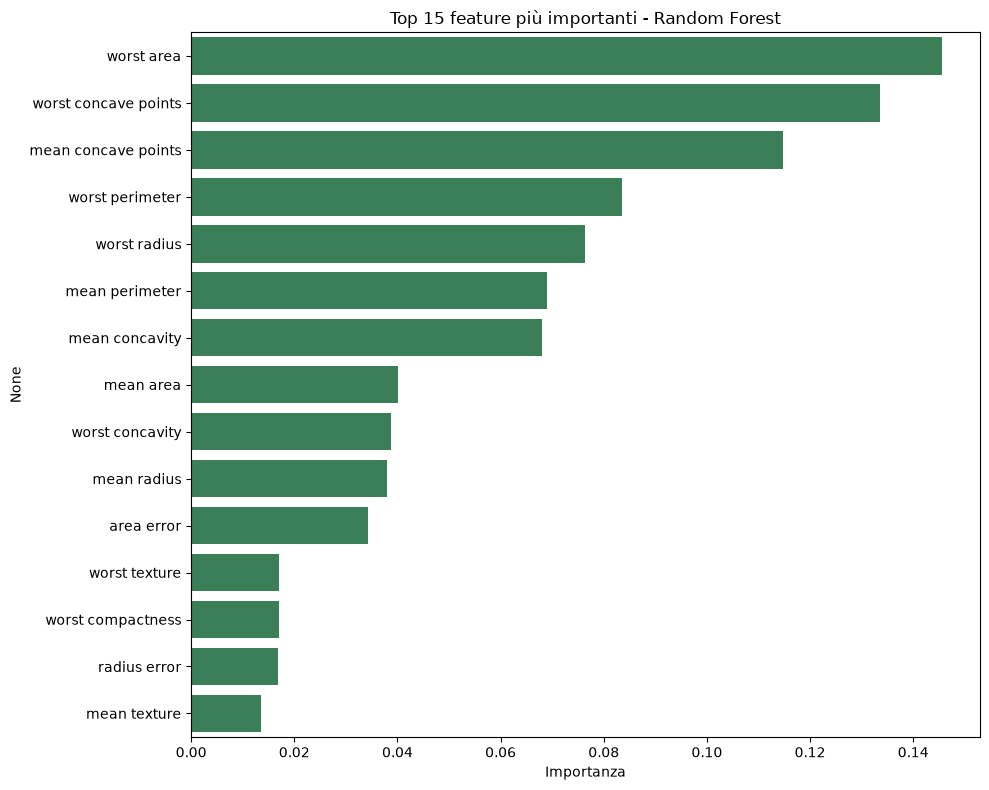

In [35]:
# Estraiamo il modello dalla pipeline per accedere a feature_importances_
rf_model = best_rf.named_steps['clf']

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color='seagreen')
plt.title('Top 15 feature più importanti - Random Forest')
plt.xlabel('Importanza')
plt.tight_layout()
plt.show()

In questo caso la Recall e la precisione non sono ottimali, creando così sia falsi negativi che falsi positivi, ma questo modello riesce a dirci meglio l'importanza di ogni feature, dando anche conferma di ciò che era risultato dall'analisi.

## 6.4 MLP

Con soli 569 campioni totali (~455 in train), una rete troppo grande andrebbe facilmente in overfitting. Pensiamo che due layer piccoli siano un punto di partenza ragionevole, è comunque un iperparametro su cui si possono fare sperimentazioni. 

In [36]:
from sklearn.neural_network import MLPClassifier

Recall media in CV: 0.96
Migliore configurazione: {'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate': 'constant', 'clf__max_iter': 500}
              precision    recall  f1-score   support

     Maligno       0.93      0.95      0.94        42
     Benigno       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



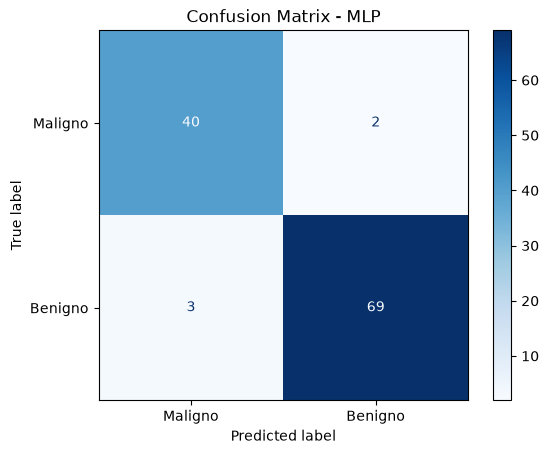

In [37]:
# Pipeline: scaler + modello (per MLP lo scaling è ancora più importante che per LogReg/SVM,
# perché la rete usa la discesa del gradiente e feature su scale diverse rallentano
# o impediscono la convergenza)
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        early_stopping=True,
        random_state=42
    ))
])

param_grid_mlp = {
    'clf__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
    'clf__max_iter': [500, 1000, 2000],
    'clf__activation': ['relu', 'tanh', 'logistic'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate': ['constant', 'adaptive']
}

grid_mlp = GridSearchCV(pipe_mlp, param_grid_mlp, cv=cv, scoring='recall_macro', n_jobs=-1)

grid_mlp.fit(X_train, y_train)

print(f"Recall media in CV: {grid_mlp.best_score_:.2f}")
print(f"Migliore configurazione: {grid_mlp.best_params_}")

# Estraiamo il modello migliore trovato dalla grid search
best_mlp = grid_mlp.best_estimator_

# Valutazione sul test set
y_pred_mlp = best_mlp.predict(X_test)

print(classification_report(y_test, y_pred_mlp, target_names=['Maligno', 'Benigno']))

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Maligno', 'Benigno'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - MLP')
plt.show()

Il modello MLP non dà risultati soddisfacenti se rapportati alla sua complessità computazionale. La Recall e la precisione non sono abbastanza alte da giustificare l'utilizzo di questo modello in casi reali, ciò è quasi sicuramente dovuto alle molto limitate dimensioni del dataset. 

# 7. Valutazione e confronto dei risultati

Avendo finito di creare i modelli passiamo ora al confronto finale

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

models_preds = {
    'Logistic Regression': y_pred_logreg,
    'SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'MLP': y_pred_mlp,
}

# pos_label=0 perché nel nostro encoding 0 = Maligno, e vogliamo le metriche
# calcolate sulla classe di interesse, non la media tra le due classi
summary = []
for name, y_pred in models_preds.items():
    summary.append({
        'Modello': name,
        'Precision (Maligno)': precision_score(y_test, y_pred, pos_label=0),
        'Recall (Maligno)': recall_score(y_test, y_pred, pos_label=0),
        'F1 (Maligno)': f1_score(y_test, y_pred, pos_label=0),
    })

summary_df = pd.DataFrame(summary).set_index('Modello')
summary_df.round(2)

,Precision (Maligno),Recall (Maligno),F1 (Maligno)
Modello,,,
Logistic Regression,0.98,0.98,0.98
SVM,0.93,0.98,0.95
Random Forest,0.91,0.95,0.93
MLP,0.93,0.95,0.94


Una volta messi a confronto, diventa evidente quando un modello semplice come la Logistic Regression sia capace di fornire i risultati migliori. Passiamo ad una visualizzazione su grafico

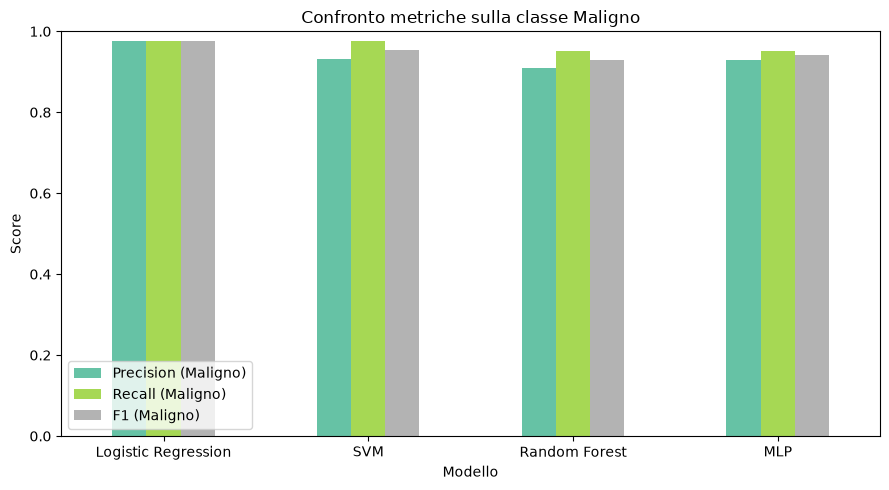

In [64]:
summary_df.plot(kind='bar', figsize=(9, 5), rot=0, colormap='Set2')
plt.title('Confronto metriche sulla classe Maligno')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Passiamo ora alla precision recall curve

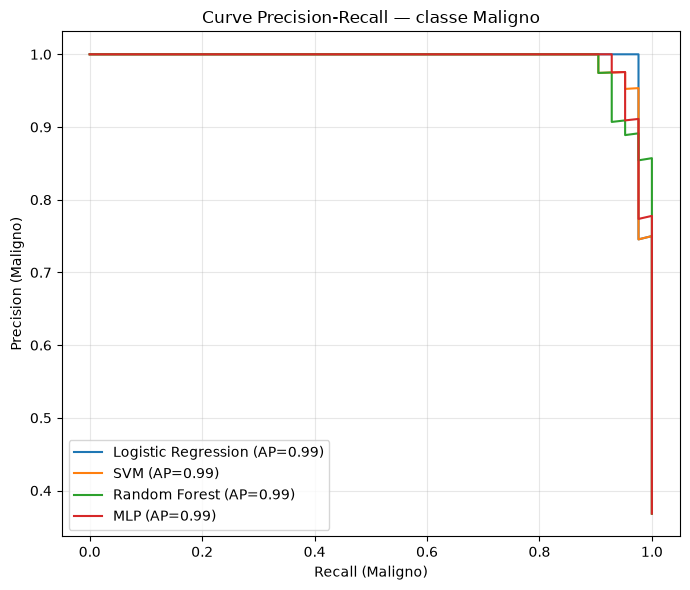

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

models_fitted = {
    'Logistic Regression': pipe_logreg,
    'SVM': best_svm,
    'Random Forest': best_rf,
    'MLP': best_mlp,
}

plt.figure(figsize=(7, 6))
for name, model in models_fitted.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 0]  # colonna classe 0 = Maligno
    else:
        y_score = -model.decision_function(X_test)  # invertiamo: score alto = Maligno

    precision, recall, _ = precision_recall_curve(y_test, y_score, pos_label=0)
    ap = average_precision_score(y_test, y_score, pos_label=0)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')

plt.xlabel('Recall (Maligno)')
plt.ylabel('Precision (Maligno)')
plt.title('Curve Precision-Recall — classe Maligno')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Anche qui emerge nuovamente e visivamente come la logistic regression batta nuovamente tutti gli altri modelli, con SVM al secondo posto e MLP al terzo. Nonostante Random Forest appaia come il più resistente nell'ultimo scalino con recall molto alta, è anche il primo a calare.

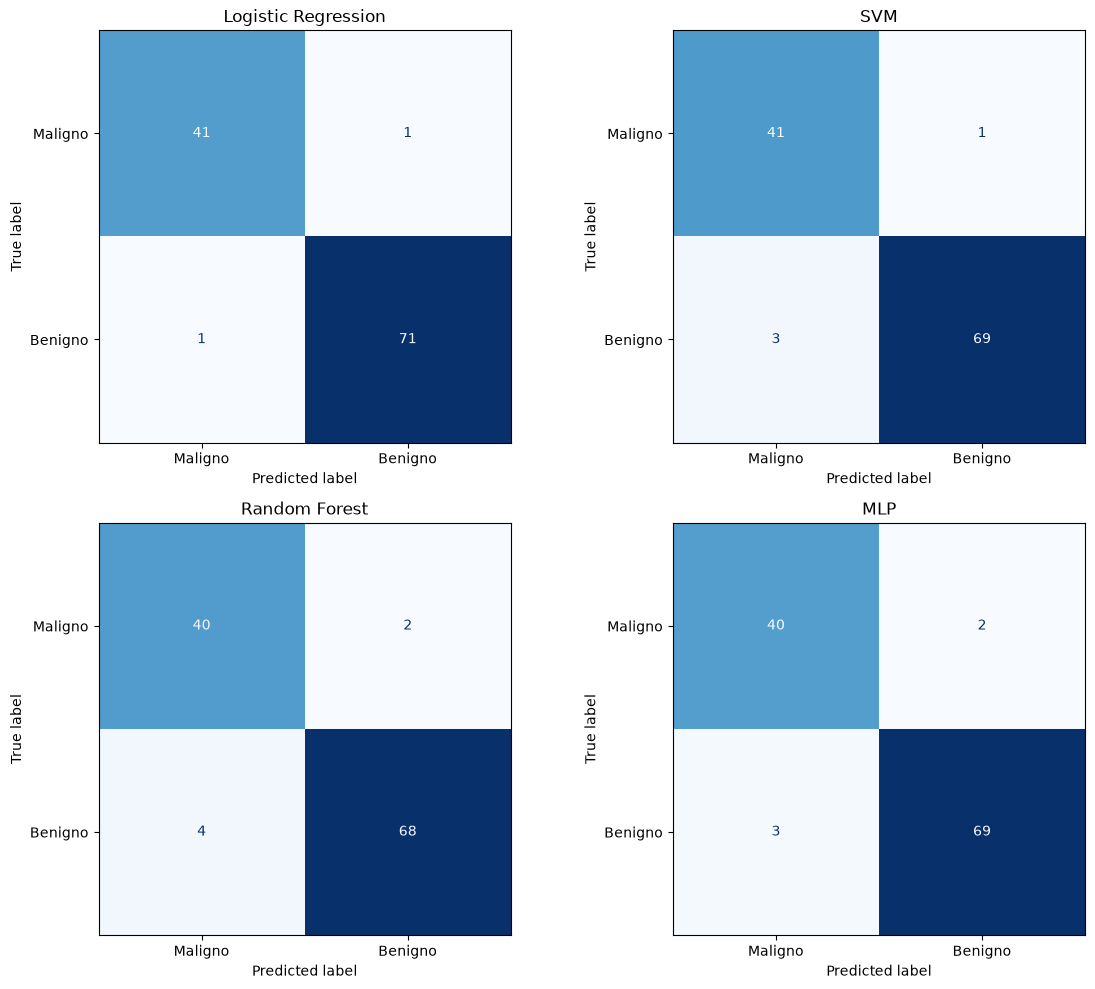

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

cms = {
    'Logistic Regression': cm_logreg,
    'SVM': cm_svm,
    'Random Forest': cm_rf,
    'MLP': cm_mlp,
}

for ax, (name, cm) in zip(axes, cms.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Maligno', 'Benigno'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Il confronto diretto tra le confusion matrix conferma quanto già emerso: Logistic Regression e SVM commettono un solo errore di falso negativo su 42 casi maligni, mentre Random Forest e MLP ne commettono il doppio (2). Poiché nel contesto clinico un falso negativo è l'errore più grave (un tumore maligno non riconosciuto), questo singolo dato pesa più di ogni altra metrica aggregata nel decidere quale modello sia preferibile in un'ipotetica applicazione reale. Se poi prendessimo in considerazione anche la precisione, i falsi positivi sono migliori secondo la Logistic Regression, mentre triplicano nel caso di SVM e MLP e quadruplicano nel caso del Random Forest. Sempre in campo medico questo genere di errore porterebbe ad un maggior dispendio di risorse economiche e temporali che andrebbero sprecate al posto di essere impiegate per chi ne ha davvero bisogno.

# 8. Conclusioni finali

- Il problema affrontato: 
Classificazione binaria di tumori al seno (maligno vs benigno) a partire da 30 feature morfologiche estratte da immagini digitalizzate, con l'obiettivo specifico di massimizzare la recall sulla classe maligna per minimizzare i falsi negativi, il tipo di errore clinicamente più pericoloso.
- Il metodo seguito:
    - EDA che ha rivelato un moderato sbilanciamento delle classi e forte multicollinearità tra feature geometriche (area/perimeter/radius)
    - Analisi degli outlier con decisione motivata di non rimuoverli, perché concentrati proprio nella classe maligna e quindi informativi
    - Quattro modelli confrontati (Logistic Regression, SVM, Random Forest, MLP), tutti con Pipeline (scaling dentro la CV) e tuning via GridSearchCV/StratifiedKFold per i 3 più capaci, valutati sullo stesso split train/test
- I risultati principali:
Tutti i modelli hanno performance alte (AP ≈ 0.99), ma Logistic Regression e SVM emergono come i migliori, con un solo falso negativo su 42 casi maligni nel test set, contro i 2 di Random Forest e MLP. Il modello più semplice, ovvero la logistic regression, si è dimostrato anche in termini assoluti di F1 score, come il modello più preciso nonostante sia anche il più semplice. Questo è dovuto sicuramente alle dimensioni più che moderate del dataset preso in esame, dove i modello più capaci al posto di predire meglio e raggiungere o quantomeno avvicinarsi alla perfezione, sono presumibilmente andati in overfitting. Il fatto però che tutti performino comunque così bene, è segno che le due classi siano facilmente separabili linearmente, cosa emersa visivamente nell'EDA
- Le conclusioni più importanti:
    - La regressione logistica si è dimostrata il modello migliore, eguale a SVM in termini di recall, ma superiore in termini di precisione, e quindi di F1 score; portando in caso di reale utilizzo a non dover fare trattamenti debilitanti come può essere la lotta ad un tumore a persone che non ne necessitano.
    - I casi reali sono separabili linearmente e con una certa facilità, permettendo di creare modelli molto precisi anche se semplici dal punto di vista della capacità
- Limiti del lavoro svolto:
    - Dataset piccolo (569 campioni): un singolo split train/test rende la stima delle performance sensibile alla particolare suddivisione scelta; una validazione più robusta userebbe una repeated cross-validation o un dataset esterno ben più ampio
    - L'analisi degli outlier in sezione 5 era univariata; un'analisi multivariata potrebbe rivelare pattern diversi
    - Il quantitativo molto limitato di record nel dataset non garantisce che questi modelli, se utilizzati in contesti reali, producano gli stessi risultati e lavorino con la stessa precisione
